![image.png](https://i.imgur.com/a3uAqnb.png)

## 📘 Lab: Linear Regression — From Scratch to Scikit-Learn

In this lab, we explore how linear regression works — starting from theory and building up to real ML tools.

We worked with a **chemical toxicity dataset (LD50)** and followed a full machine-learning workflow:

- Load and clean data
- Explore feature relationships and distributions
- Standardize input features
- Implement linear regression **from scratch**
  - Normal Equation (closed-form solution)
  - Gradient Descent (NumPy)
- Use scikit-learn implementations
  - `LinearRegression` (analytical solution)
  - `SGDRegressor` (gradient descent)

This progression shows how models learn, how parameters are optimized, and how real-world ML libraries automate the process.




---



### 📦 Importing Libraries

In this section, we import all the necessary Python packages used throughout the tutorial:

- **os** – Interacts with the operating system (useful for file paths).
- **pandas** – Handles data loading and manipulation using DataFrames.
- **kagglehub** – Enables direct dataset access from Kaggle.
- **numpy** – Supports numerical operations and array manipulation.
- **matplotlib.pyplot** – Used for creating visualizations and plots.

#### 🧠 Scikit-Learn (Machine Learning tools)
- `SGDRegressor` – Linear model trained using **Stochastic Gradient Descent**.
- `LinearRegression` – Traditional Ordinary Least Squares regression.
- `mean_squared_error`, `r2_score` – Model evaluation metrics.
- `train_test_split` – Splits data into training and testing sets.
- `StandardScaler` – Standardizes features (mean=0, std=1) to improve training stability.

These imports set up the entire ML workflow: data loading → preprocessing → modeling → evaluation → visualization.


In [26]:
import os
import pandas as pd
import kagglehub
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### 📥 Downloading the Dataset from Kaggle

Here we use **kagglehub** to automatically download our dataset from Kaggle:




In [27]:
path = kagglehub.dataset_download("hillarymongare/ld50-smiles-descriptors-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ld50-smiles-descriptors-dataset' dataset.
Path to dataset files: /kaggle/input/ld50-smiles-descriptors-dataset


In [28]:
df = pd.read_csv(os.path.join(path, 'ld50-smiles-descriptors-dataset.csv'))
df

,Name,SMILES,LD50,BertzCT,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HeavyAtomCount,...,NumHAcceptors,NumHDonors,NumHeteroatoms,RingCount,SMR_VSA10,SlogP_VSA12,SlogP_VSA5,VSA_EState4,VSA_EState9,qed
0,4-nitroaniline,Nc1ccc([N+](=O)[O-])cc1,2.265,242.429658,1.848642,1.103907,1.103907,0.596038,0.596038,10,...,3,1,4,1,11.374773,0.000000,0.000000,5.901255,0.000000,0.359544
1,4-nitrophenol,O=[N+]([O-])c1ccc(O)cc1,2.838,241.674771,1.773508,1.060528,1.060528,0.574349,0.574349,10,...,3,1,4,1,5.687386,0.000000,0.000000,-0.015926,0.000000,0.470728
2,1-(chloromethyl)-4-nitrobenzene,O=[N+]([O-])c1ccc(CCl)cc1,1.977,257.648013,2.324449,1.301462,1.610069,0.706751,0.884925,11,...,2,0,4,1,17.288326,11.600940,5.563451,0.982531,0.000000,0.389482
3,1-methoxy-4-nitrobenzene,COc1ccc([N+](=O)[O-])cc1,1.823,254.893126,1.955135,1.283242,1.283242,0.703937,0.703937,11,...,3,0,4,1,5.687386,0.000000,0.000000,0.074815,1.515046,0.478623
4,"benzene-1,4-dicarbonyl chloride",O=C(Cl)c1ccc(C(=O)Cl)cc1,1.910,283.334675,2.811331,1.338820,1.775256,0.732299,0.984275,12,...,2,0,4,1,33.686733,23.201880,20.715977,0.691358,0.000000,0.691354
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7392,"n,n-diethyl-6-nitro-2-sulfanylidene-4h-1,3,2la...",CCN(CC)P1(=S)OCc2cc([N+](=O)[O-])ccc2O1,3.304,547.496765,7.349216,2.928262,6.302228,1.892426,4.737466,19,...,5,0,8,2,24.136641,6.642399,19.410926,0.699835,0.000000,0.483642
7393,"n,n-dimethyl-6-nitro-2-sulfanylidene-4h-1,3,2l...",CN(C)P1(=S)OCc2cc([N+](=O)[O-])ccc2O1,3.341,519.717360,7.291839,NaN,5.723925,1.380144,2.955014,17,...,5,0,8,2,24.136641,6.642399,5.563451,0.678268,3.577701,0.468119
7394,acetyloxymethyl 3-(carbamoyloxymethyl)-6-(1-hy...,CC(=O)OCOC(=O)C1=C(COC(N)=O)SC2C(C(C)O)C(=O)N12,1.698,617.092952,6.259586,3.363105,4.704351,2.315969,3.832894,24,...,9,2,11,2,35.700915,11.761885,13.847474,4.795315,0.000000,0.355392
7395,methyl-bis(propylsulfanyl)-sulfanylidene-lambd...,CCCSP(C)(=S)SCCC,4.103,123.647376,15.515421,1.059840,10.883802,0.551487,8.317488,11,...,3,0,4,0,39.011839,27.204983,26.689118,0.000000,0.000000,0.624970


### 📊 Understanding Key Dataset Columns

This dataset contains molecular descriptors (numeric features extracted from chemical structures) along with the toxicity value **LD50**. Here are brief explanations of the most important columns:

| Column | Meaning | Why it Matters |
|--------|--------|----------------|
| **LD50** | Median lethal dose (toxicity measure). Lower = more toxic. | ✅ **Target variable** we try to predict |
| **BertzCT** | Bertz complexity index — measures molecular complexity. | Complex molecules often show different biological behavior |
| **Chi2v, Chi3v, Chi4v** | Valence connectivity indices — graph-based molecule shape descriptors. | Encodes how atoms connect, influencing toxicity |
| **Chi3n, Chi4n** | Atomic connectivity (non-valence versions) | Helps quantify structural branching |
| **HeavyAtomCount** | Number of non-hydrogen atoms | Basic molecule size indicator |
| **HeavyAtomMolWt** | Molecular weight based on heavy atoms | Toxicity can correlate with molecular mass |
| **Kappa3** | Shape index — measures molecular flexibility/shape | Molecule shape affects biological activity |
| **MaxPartialCharge / MinPartialCharge** | Highest/lowest atomic partial charge in molecule | Charge distribution impacts interaction with proteins |
| **MinAbsPartialCharge** | Minimum absolute partial charge | Indicates polarity and reactivity |
| **MinEStateIndex** | Electronic state descriptor | Captures electron distribution influencing toxicity |
| **MolLogP** | LogP (lipophilicity) — how fat-soluble the compound is | Highly lipophilic molecules may penetrate cell membranes easily |
| **MolWt** | Molecular weight | Common physical property in toxicity modeling |
| **NumHAcceptors / NumHDonors** | Hydrogen bond acceptor/donor counts | Affects solubility + biological binding |
| **NumHeteroatoms** | Number of non-carbon atoms | Heteroatoms influence reactivity/toxicity |
| **RingCount** | Number of rings in the molecule | Cyclic structures influence stability and toxicity |
| **SMR_VSA / SlogP_VSA** | Surface area descriptors weighted by molar refractivity or logP | Encodes shape + chemical reactivity |
| **VSA_EState** | Electronic state surface area descriptors | Useful for QSAR (structure–activity) modeling |
| **qed** | "Quantitative Estimation of Drug-likeness" score | Higher = more drug-like properties (not toxicity directly but correlated with chemistry traits) |

---

### 💡 Key takeaway

These descriptors convert molecules into **numeric features** that machine learning models can use. They capture:

- Size and shape
- Electronic properties
- Polarity and charge
- Lipophilicity (fat-solubility)
- Structural complexity

Together, they help predict **chemical toxicity (LD50)** — a classic **QSAR** (Quantitative Structure-Activity Relationship) task.



In [29]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
LD50,7396.0,2.554190,0.951690,0.291000,1.867000,2.378000,3.044000,7.207000
BertzCT,7392.0,400.140968,305.446876,2.000000,169.256513,351.572890,552.137280,4025.484341
Chi2v,7389.0,4.908541,2.950234,0.000000,2.784621,4.318588,6.462885,26.092602
Chi3n,7389.0,2.473274,1.832664,0.000000,1.308924,2.050387,3.171446,21.050990
Chi3v,7389.0,3.366371,2.459651,0.000000,1.651111,2.809473,4.516022,23.784903
Chi4n,7393.0,1.622177,1.436304,0.000000,0.724270,1.259558,2.122591,16.235218
Chi4v,7394.0,2.282153,2.052736,0.000000,0.944832,1.785409,3.046399,31.500000
HeavyAtomCount,7397.0,16.169258,7.705312,2.000000,11.000000,15.000000,20.000000,90.000000
HeavyAtomMolWt,7396.0,232.049389,109.232519,26.018000,152.108000,218.183500,292.240250,1247.715000
Kappa3,7394.0,7.799745,160.977491,-27.040000,2.058290,3.275854,4.856951,9507.960000


### 🧹 Removing Missing Values (NaNs)

The dataset contains about **66 rows with missing values**, which is small compared to the full size.  
To keep things simple and ensure clean input for our model, we **drop those rows** instead of filling them.

This step guarantees the dataset is fully numeric and ready for training.


In [30]:
nan_rows = df.isna().any(axis=1).sum()
print(f"Number of rows with at least one NaN: {nan_rows}")

df = df.dropna()

nan_rows = df.isna().any(axis=1).sum()
print(f"Number of rows with at least one NaN: {nan_rows}")

Number of rows with at least one NaN: 66
Number of rows with at least one NaN: 0


In [31]:
df = df.drop(columns=["Name", "SMILES"])

In [32]:
df.dtypes

,0
LD50,float64
BertzCT,float64
Chi2v,float64
Chi3n,float64
Chi3v,float64
Chi4n,float64
Chi4v,float64
HeavyAtomCount,int64
HeavyAtomMolWt,float64
Kappa3,float64


### 📊 LD50 Distribution

Here we visualize the distribution of the **LD50** values, which represent compound toxicity (mg/kg).

- Shows how toxicity values are spread across the dataset  
- Helps detect skewness or extreme values (common in toxicity data)  
- Understanding the target distribution helps guide model expectations  

This quick plot gives us insight into how toxic compounds vary in the dataset.


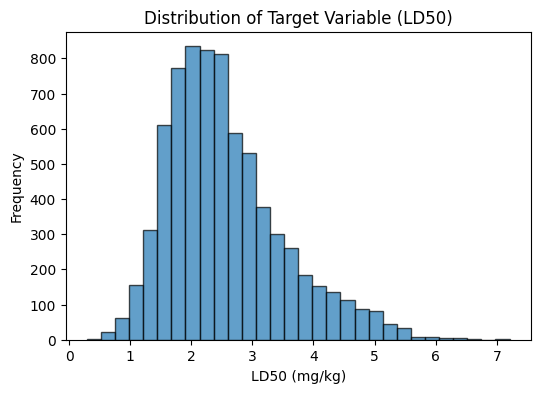

In [33]:
# Plot distribution of the target variable
plt.figure(figsize=(6,4))
plt.hist(df["LD50"], bins=30, edgecolor='k', alpha=0.7)
plt.xlabel("LD50 (mg/kg)")
plt.ylabel("Frequency")
plt.title("Distribution of Target Variable (LD50)")
plt.show()


### 📎 Checking Feature Correlation with Toxicity (LD50)

We compute the correlation between each feature and the **log-scaled LD50** target, then list the top 10.

> **Important:** In this dataset, **lower LD50 = more toxic compound**.  
So:
- **Positive correlation** → feature increases when LD50 increases → **less toxic**
- **Negative correlation** → feature increases when LD50 decreases → **more toxic**

This helps us identify which molecular descriptors are most linked to chemical toxicity.


In [34]:
# Check correlation of top features with LD50
corr = df.corr()["LD50"].sort_values(ascending=False)
corr.head(10)


,LD50
LD50,1.000000
Chi3v,0.375348
NumHeteroatoms,0.368207
Chi2v,0.355314
Chi4v,0.347843
HeavyAtomMolWt,0.332348
SMR_VSA10,0.324246
MolWt,0.320151
SlogP_VSA12,0.288619
MaxPartialCharge,0.270902


### 🧩 Preparing Features and Target

- We separate the dataset into:
  - **X** → input features (molecular descriptors)
  - **y** → target variable (`log_LD50`)

- Then we convert them to NumPy arrays for compatibility with machine learning models.

This step formats the data so it’s ready for training.


In [35]:
# Split features (X) and target (y)
X = df.drop(columns=["LD50"])
y = df["LD50"]

# Convert to numpy arrays
X = X.values
y = y.values.reshape(-1, 1)


### ✂️ Train/Test Split + 🔄 Feature Scaling

- We split the data into **training (80%)** and **testing (20%)** sets to evaluate model performance fairly.
- Then we apply **StandardScaler** to normalize the features:
  - `fit_transform()` learns scaling parameters on the training data and applies them
  - `transform()` applies the same scaling to the test data (no data leakage ✅)

Normalizing ensures all features have similar scale, which improves model stability and training efficiency.


In [36]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train_scaled.shape)
print("Testing set shape:", X_test_scaled.shape)


Training set shape: (5864, 25)
Testing set shape: (1467, 25)


### 🤖 Linear Regression Using Scikit-Learn

Here we use `LinearRegression()` from scikit-learn to fit our model automatically.

**What happens:**
- `model.fit(...)` learns the best weights and bias using the normal equation internally
- We make predictions on both training and test data
- We compute **Mean Squared Error (MSE)** to measure model performance

This gives us a fast, reliable baseline model without manually coding the math.


In [45]:
# Train model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predict
X_pred = model.predict(X_train_scaled)
y_pred = model.predict(X_test_scaled)

# Evaluate
train_mse = mean_squared_error(y_train, X_pred)
test_mse = mean_squared_error(y_test, y_pred)

print(f"Train MSE: {train_mse:4f}")
print(f"Test MSE: {test_mse:.4f}")


Train MSE: 0.667118
Test MSE: 0.6006


### ⚙️ Linear Regression Using Gradient Descent (SGDRegressor)

Here we use scikit-learn’s `SGDRegressor`, which trains a linear regression model using **stochastic gradient descent (SGD)** instead of the closed-form solution.

**Key points:**
- `max_iter=1000` → number of passes over the training data (epochs)
- Model updates weights **incrementally** per batch/sample
- Useful for **large datasets** where normal equation is expensive

We then:
- Fit the model on the training data
- Predict on train & test sets
- Compute **MSE** to compare performance

This approach mirrors the manual gradient descent method, but uses an optimized scikit-learn implementation.


In [46]:
# Initialize the SGDRegressor (stochastic gradient descent)
gd_model = SGDRegressor(
    max_iter=1000,     # number of epochs
)

# Train model using gradient descent
gd_model.fit(X_train_scaled, y_train.ravel())

# Predict
y_train_pred = gd_model.predict(X_train_scaled)
y_test_pred = gd_model.predict(X_test_scaled)

# Evaluate
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# Display results
print("Linear Regression (Gradient Descent via SGDRegressor)")
print(f"Train MSE: {train_mse:.4f}")
print(f"Test MSE:  {test_mse:.4f}")



Linear Regression (Gradient Descent via SGDRegressor)
Train MSE: 0.6745
Test MSE:  0.6082


## ✅ Summary

In this lab, we:

- Built linear regression models manually and using scikit-learn
- Understood the math behind **Normal Equation** and **Gradient Descent**
- Compared hand-written logic to optimized ML frameworks
- Evaluated models using **Mean Squared Error (MSE)**
- Observed that proper **scaling** improves model performance

Key takeaway:  
> While deep-learning tools automate optimization, understanding gradient descent gives us the foundation to design and tune modern models.

---

## 💬 Discussion Questions

1. What advantages does gradient descent provide over the closed-form normal equation?
2. Why is feature scaling critical when using gradient-based models?
3. How might outliers or skewed data influence linear regression performance?
4. If your MSE is low on training but high on testing, what might be happening?

---

## 🎯 Optional Challenge

Try increasing the number of features or experimenting with:

- Different learning rates
- More/less training epochs
- Mini-batch gradient descent

This helps build intuition on how optimization parameters affect learning speed and model accuracy.


### Contributed by: Yazan Alshoibi